In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("loan_train.csv")

In [4]:
df.head()

,Unnamed: 0,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,LP002305,Female,No,0,Graduate,No,4547,0.0,115.0,360.0,1.0,Semiurban,1
1,1,LP001715,Male,Yes,3+,Not Graduate,Yes,5703,0.0,130.0,360.0,1.0,Rural,1
2,2,LP002086,Female,Yes,0,Graduate,No,4333,2451.0,110.0,360.0,1.0,Urban,0
3,3,LP001136,Male,Yes,0,Not Graduate,Yes,4695,0.0,96.0,NaN,1.0,Urban,1
4,4,LP002529,Male,Yes,2,Graduate,No,6700,1750.0,230.0,300.0,1.0,Semiurban,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         491 non-null    int64  
 1   Loan_ID            491 non-null    object 
 2   Gender             481 non-null    object 
 3   Married            490 non-null    object 
 4   Dependents         482 non-null    object 
 5   Education          491 non-null    object 
 6   Self_Employed      462 non-null    object 
 7   ApplicantIncome    491 non-null    int64  
 8   CoapplicantIncome  491 non-null    float64
 9   LoanAmount         475 non-null    float64
 10  Loan_Amount_Term   478 non-null    float64
 11  Credit_History     448 non-null    float64
 12  Property_Area      491 non-null    object 
 13  Loan_Status        491 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 53.8+ KB


In [6]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 491
Columnas: 14


In [7]:
df.isnull().sum()

Unnamed: 0            0
Loan_ID               0
Gender               10
Married               1
Dependents            9
Education             0
Self_Employed        29
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     13
Credit_History       43
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
df.fillna({
    'Gender': df['Gender'].mode()[0],
    'Married': df['Married'].mode()[0],
    'Dependents': df['Dependents'].mode()[0],
    'Self_Employed': df['Self_Employed'].mode()[0],
    'LoanAmount': df['LoanAmount'].median(),
    'Loan_Amount_Term': df['Loan_Amount_Term'].median(),
    'Credit_History': df['Credit_History'].mode()[0]
}, inplace=True)

In [9]:
df.isnull().sum()

Unnamed: 0           0
Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [10]:
total_loans = len(df)

print("Total de solicitudes:", total_loans)

Total de solicitudes: 491


In [11]:
approved = df['Loan_Status'].sum()

print("Préstamos aprobados:", approved)

Préstamos aprobados: 343


In [12]:
approval_rate = (approved / total_loans) * 100

print(f"Tasa de aprobación: {approval_rate:.2f}%")

Tasa de aprobación: 69.86%


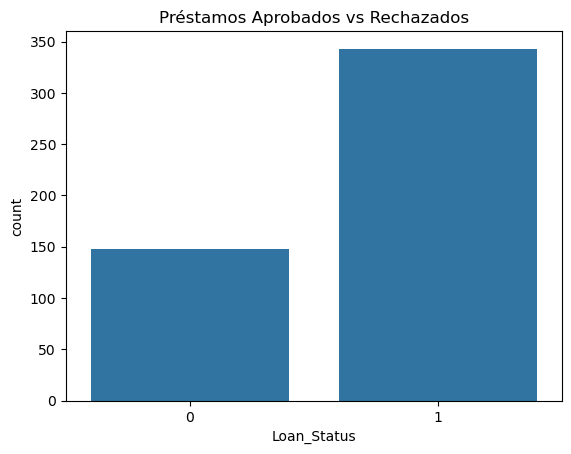

In [13]:
sns.countplot(
    data=df,
    x='Loan_Status'
)

plt.title('Préstamos Aprobados vs Rechazados')

plt.show()

In [1]:
pd.crosstab(
    df['Credit_History'],
    df['Loan_Status']
)

NameError: name 'pd' is not defined

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("loan_train.csv")

In [5]:
pd.crosstab(
    df['Credit_History'],
    df['Loan_Status']
)

Loan_Status,0,1
Credit_History,,
0.0,62,6
1.0,74,306


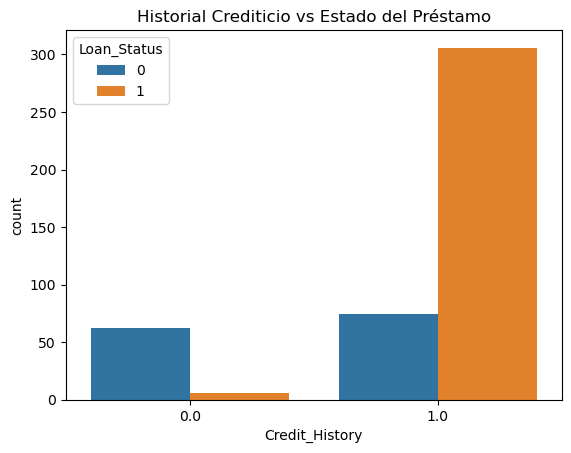

In [6]:
sns.countplot(
    data=df,
    x='Credit_History',
    hue='Loan_Status'
)

plt.title('Historial Crediticio vs Estado del Préstamo')

plt.show()

In [7]:
df.groupby('Loan_Status')['ApplicantIncome'].mean()

Loan_Status
0    5398.135135
1    5402.507289
Name: ApplicantIncome, dtype: float64

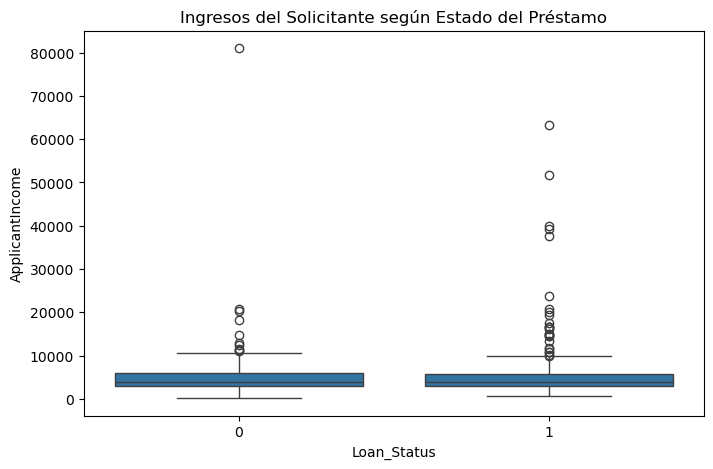

In [8]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Loan_Status',
    y='ApplicantIncome'
)

plt.title('Ingresos del Solicitante según Estado del Préstamo')

plt.show()

In [9]:
pd.crosstab(
    df['Married'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,0,1
Married,,
No,38.554217,61.445783
Yes,25.925926,74.074074


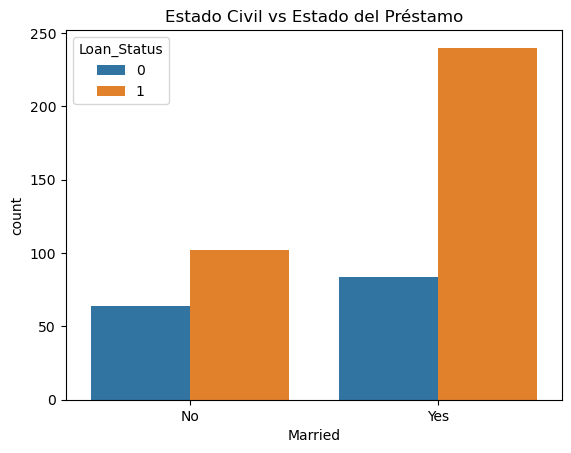

In [10]:
sns.countplot(
    data=df,
    x='Married',
    hue='Loan_Status'
)

plt.title('Estado Civil vs Estado del Préstamo')

plt.show()

In [11]:
df.groupby('Loan_Status')['LoanAmount'].mean()

Loan_Status
0    148.518248
1    143.594675
Name: LoanAmount, dtype: float64

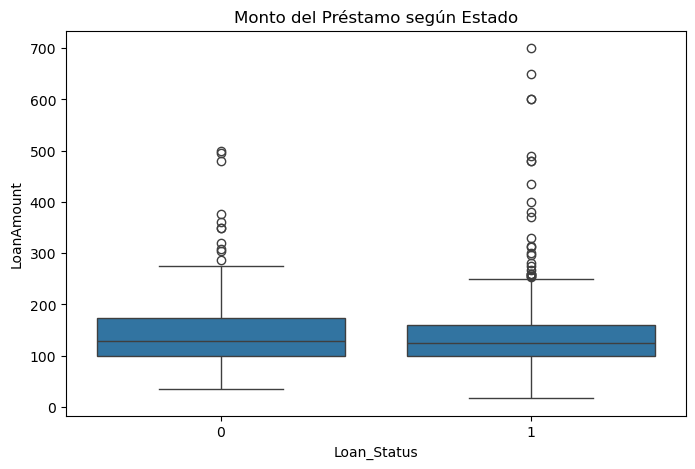

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Loan_Status',
    y='LoanAmount'
)

plt.title('Monto del Préstamo según Estado')

plt.show()

In [13]:
pd.crosstab(
    df['Education'],
    df['Loan_Status'],
    normalize='index'
) * 100

Loan_Status,0,1
Education,,
Graduate,28.350515,71.649485
Not Graduate,36.893204,63.106796


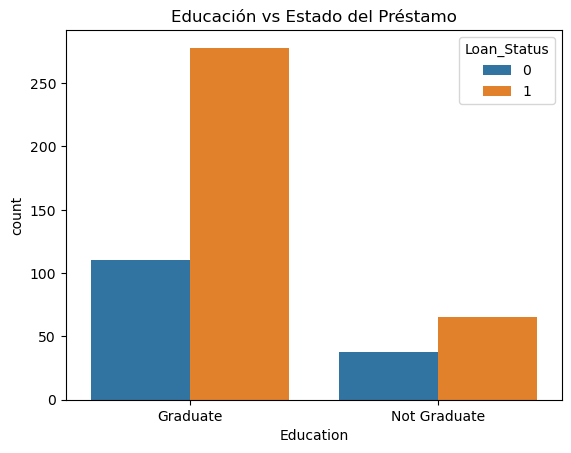

In [14]:
sns.countplot(
    data=df,
    x='Education',
    hue='Loan_Status'
)

plt.title('Educación vs Estado del Préstamo')

plt.show()

In [15]:
pd.crosstab(
    df['Dependents'],
    df['Loan_Status']
)

Loan_Status,0,1
Dependents,,
0,81,195
1,31,54
2,16,62
3+,16,27


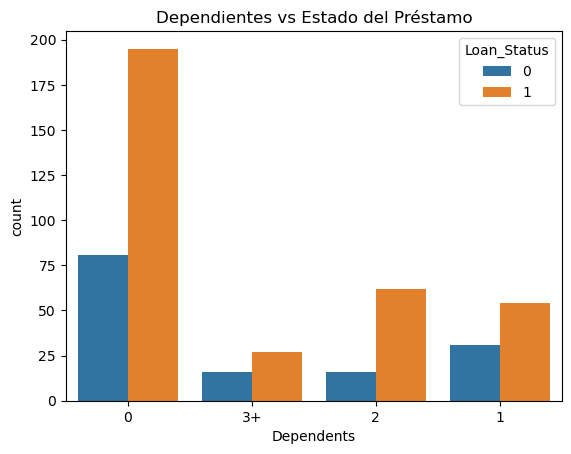

In [16]:
sns.countplot(
    data=df,
    x='Dependents',
    hue='Loan_Status'
)

plt.title('Dependientes vs Estado del Préstamo')

plt.show()

In [17]:
rejected = total_loans - approved

print("Total Solicitudes:", total_loans)
print("Préstamos Aprobados:", approved)
print("Préstamos Rechazados:", rejected)
print(f"Tasa de Aprobación: {approval_rate:.2f}%")

NameError: name 'total_loans' is not defined

In [18]:
total_loans = len(df)

print("Total de solicitudes:", total_loans)

Total de solicitudes: 491


In [20]:
approved = df['Loan_Status'].sum()

print("Préstamos aprobados:", approved)

Préstamos aprobados: 343


In [22]:
approval_rate = (approved / total_loans) * 100

print(f"Tasa de aprobación: {approval_rate:.2f}%")

Tasa de aprobación: 69.86%


In [23]:
rejected = total_loans - approved

print("Total Solicitudes:", total_loans)
print("Préstamos Aprobados:", approved)
print("Préstamos Rechazados:", rejected)
print(f"Tasa de Aprobación: {approval_rate:.2f}%")

Total Solicitudes: 491
Préstamos Aprobados: 343
Préstamos Rechazados: 148
Tasa de Aprobación: 69.86%


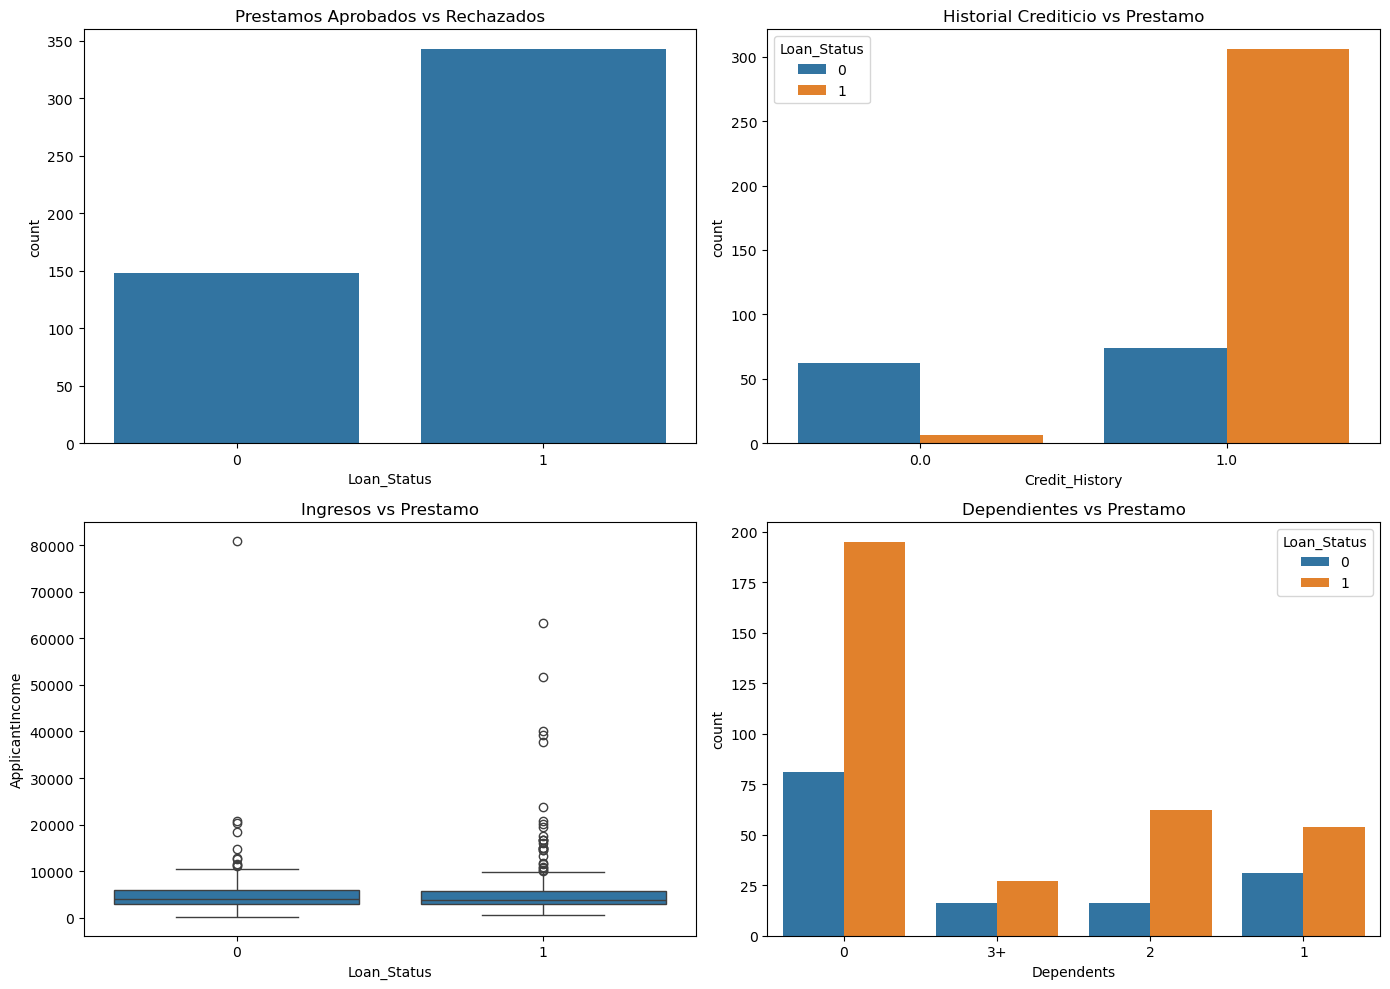

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Grafico 1
sns.countplot(
    data=df,
    x='Loan_Status',
    ax=axes[0,0]
)

axes[0,0].set_title('Prestamos Aprobados vs Rechazados')

# Grafico 2
sns.countplot(
    data=df,
    x='Credit_History',
    hue='Loan_Status',
    ax=axes[0,1]
)

axes[0,1].set_title('Historial Crediticio vs Prestamo')

# Grafico 3
sns.boxplot(
    data=df,
    x='Loan_Status',
    y='ApplicantIncome',
    ax=axes[1,0]
)

axes[1,0].set_title('Ingresos vs Prestamo')

# Grafico 4
sns.countplot(
    data=df,
    x='Dependents',
    hue='Loan_Status',
    ax=axes[1,1]
)

axes[1,1].set_title('Dependientes vs Prestamo')

plt.tight_layout()

plt.show()